# 01 · Dataset Analysis — Bahraini Food Detector

**Lab Section 6 — Dataset Quality Check.**

This notebook reads the dataset you exported from **Roboflow** (YOLO format) and
reports everything the lab asks for *before* training:

- images in train / validation / test
- number of objects per class, and number of images containing each class
- average objects per image
- a **chart of annotated objects per class** (required deliverable)
- obvious class imbalance
- examples of good vs. questionable annotations

> **How to use:** export your labeled dataset from Roboflow as **YOLOv11** into the
> `datasets/` folder (so there is a `datasets/.../data.yaml`), then run all cells.

In [5]:
# ===== Colab setup - runs only on Google Colab, harmless on local Jupyter =====
import os
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False
if _IN_COLAB and not os.path.exists('src/utils.py'):
    !git clone https://github.com/hymoo2002/Bahrain-Food-Detector.git
    os.chdir('Bahrain-Food-Detector')
    !pip install -q -U ultralytics roboflow
    print('Colab ready - cwd:', os.getcwd())

In [6]:
# %pip install -q numpy pandas matplotlib pyyaml pillow

In [7]:
import os, sys, random
cwd = os.getcwd()
ROOT = os.path.abspath(os.path.join(cwd, "..")) if os.path.basename(cwd).lower() == "notebooks" else cwd
sys.path.insert(0, os.path.join(ROOT, "src"))
import importlib.util as _ilu
_upath = os.path.join(ROOT, "src", "utils.py")
assert os.path.exists(_upath), "src/utils.py not found - on Colab, git clone your repo first (see cell 1)."
_uspec = _ilu.spec_from_file_location("food_utils", _upath)
U = _ilu.module_from_spec(_uspec); _uspec.loader.exec_module(U)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

# ---- CONFIG -------------------------------------------------------------
# Point this at the Roboflow export folder that contains `data.yaml`.
# Leave as None to auto-search under ./datasets for the first data.yaml.
DATASET_DIR = None

RESULTS_DIR = os.path.join(ROOT, "results"); os.makedirs(RESULTS_DIR, exist_ok=True)
data_yaml = U.find_data_yaml(DATASET_DIR or os.path.join(ROOT, "datasets"))
assert data_yaml, "No data.yaml found. Export your dataset from Roboflow into ./datasets first."
print("Using:", data_yaml)

data = U.load_data_yaml(data_yaml)
print("Classes (", data["nc"], "):", data["names"])
for s, d in data["splits"].items():
    print(f"  {s:5s} -> {d}")

Using: C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW\data.yaml
Classes ( 10 ): ['Balaleet', 'Fried Fish', 'Halwa', 'Harees', 'Kebab', 'Luqaimat', 'Machboos', 'Mattai', 'Nakhi', 'Samboosa']
  train -> C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW\train\images
  val   -> C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW\valid\images
  test  -> C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW\test\images


## 1 · Images per split

In [8]:
stats = U.dataset_stats(data)
display(stats["per_split"])
print("Total images :", stats["total_images"])
print("Total objects:", stats["total_objects"])
print("Avg objects/image:", stats["avg_objects_per_image"])
print("(Lab minimums: >=300 images total, 30-40 images per class.)")

,images,objects,avg_objects_per_image
train,369,428,1.16
val,105,113,1.08
test,53,60,1.13


Total images : 527
Total objects: 601
Avg objects/image: 1.14
(Lab minimums: >=300 images total, 30-40 images per class.)


## 2 · Objects per class & images per class

In [9]:
print("Objects per class (per split + total):")
display(stats["objects_per_class"])
print("Number of images containing each class:")
display(stats["images_per_class"])

Objects per class (per split + total):


,train,val,test,total
Balaleet,45,12,4,61
Fried Fish,47,7,6,60
Halwa,34,18,8,60
Harees,44,14,2,60
Kebab,40,11,9,60
Luqaimat,45,13,2,60
Machboos,46,9,5,60
Mattai,39,11,10,60
Nakhi,47,6,7,60
Samboosa,41,12,7,60


Number of images containing each class:


,train,val,test,total
Balaleet,41,12,4,57
Fried Fish,46,7,6,59
Halwa,29,16,8,53
Harees,43,14,2,59
Kebab,29,9,6,44
Luqaimat,26,12,2,40
Machboos,45,8,5,58
Mattai,32,11,7,50
Nakhi,40,6,6,52
Samboosa,38,10,7,55


## 3 · Chart — annotated objects per class  *(required deliverable)*

saved C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\results\objects_per_class.png


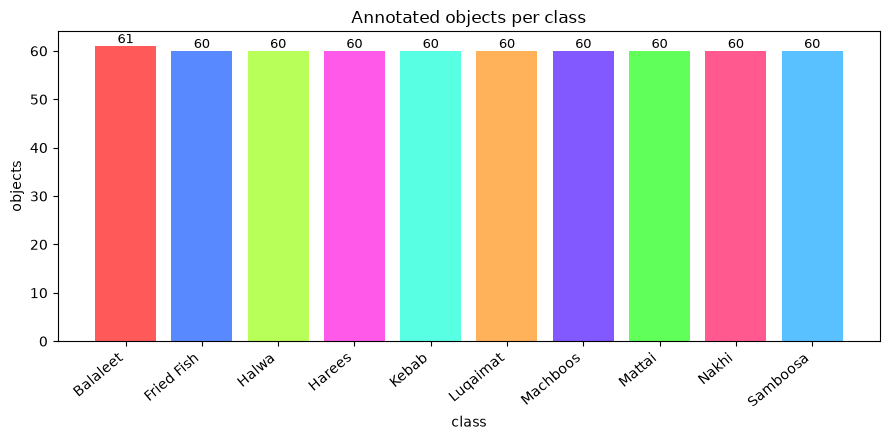

In [10]:
obj = stats["objects_per_class"]["total"].sort_values(ascending=False)
colors = [tuple(c/255 for c in U.class_color(list(data["names"]).index(name))) for name in obj.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(obj.index, obj.values, color=colors)
ax.set_title("Annotated objects per class"); ax.set_ylabel("objects"); ax.set_xlabel("class")
plt.xticks(rotation=40, ha="right")
for i, v in enumerate(obj.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
out = os.path.join(RESULTS_DIR, "objects_per_class.png")
plt.savefig(out, dpi=130); print("saved", out); plt.show()

## 4 · Split distribution & objects-per-image

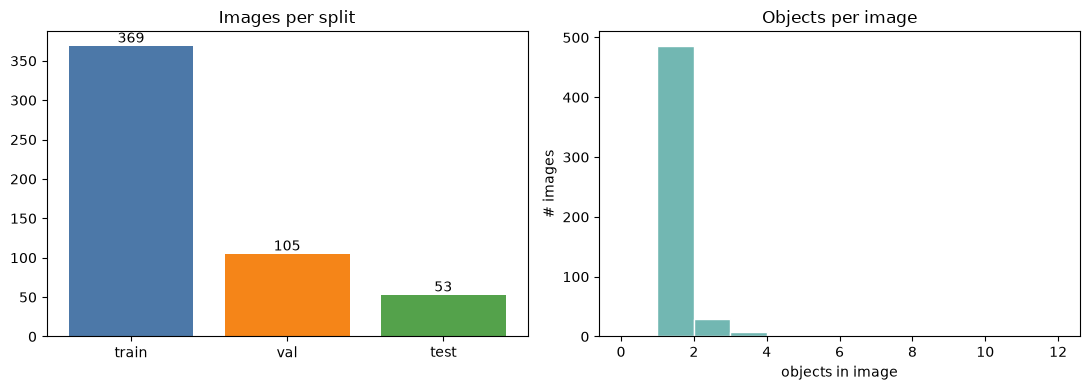

In [11]:
sp = stats["per_split"]
counts = []
for s, d in data["splits"].items():
    for img in U.list_images(d):
        counts.append(len(U.read_yolo_label(U.label_path_for_image(img))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(sp.index, sp["images"], color=["#4c78a8", "#f58518", "#54a24b"])
axes[0].set_title("Images per split")
for i, v in enumerate(sp["images"]):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom")
if counts:
    axes[1].hist(counts, bins=range(0, max(counts) + 2), color="#72b7b2", edgecolor="white")
axes[1].set_title("Objects per image"); axes[1].set_xlabel("objects in image"); axes[1].set_ylabel("# images")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dataset_distributions.png"), dpi=130); plt.show()

## 5 · Class imbalance check

In [12]:
ratio = stats["imbalance_ratio"]
per = stats["objects_per_class"]["total"]
print(f"Imbalance ratio (max objects / min objects) = {ratio:.2f}")
print("Most common :", per.idxmax(), int(per.max()))
print("Least common:", per.idxmin(), int(per.min()))
if ratio >= 3:
    print("WARNING: notable class imbalance (>=3x). Collect more images of the rare classes.")
else:
    print("OK: balance looks reasonable (<3x).")

Imbalance ratio (max objects / min objects) = 1.02
Most common : Balaleet 61
Least common: Fried Fish 60
OK: balance looks reasonable (<3x).


## 6 · Examples of good annotations
Random **training** images with ground-truth boxes drawn. Check by eye: are the boxes
tight around the food and labeled with the correct class?

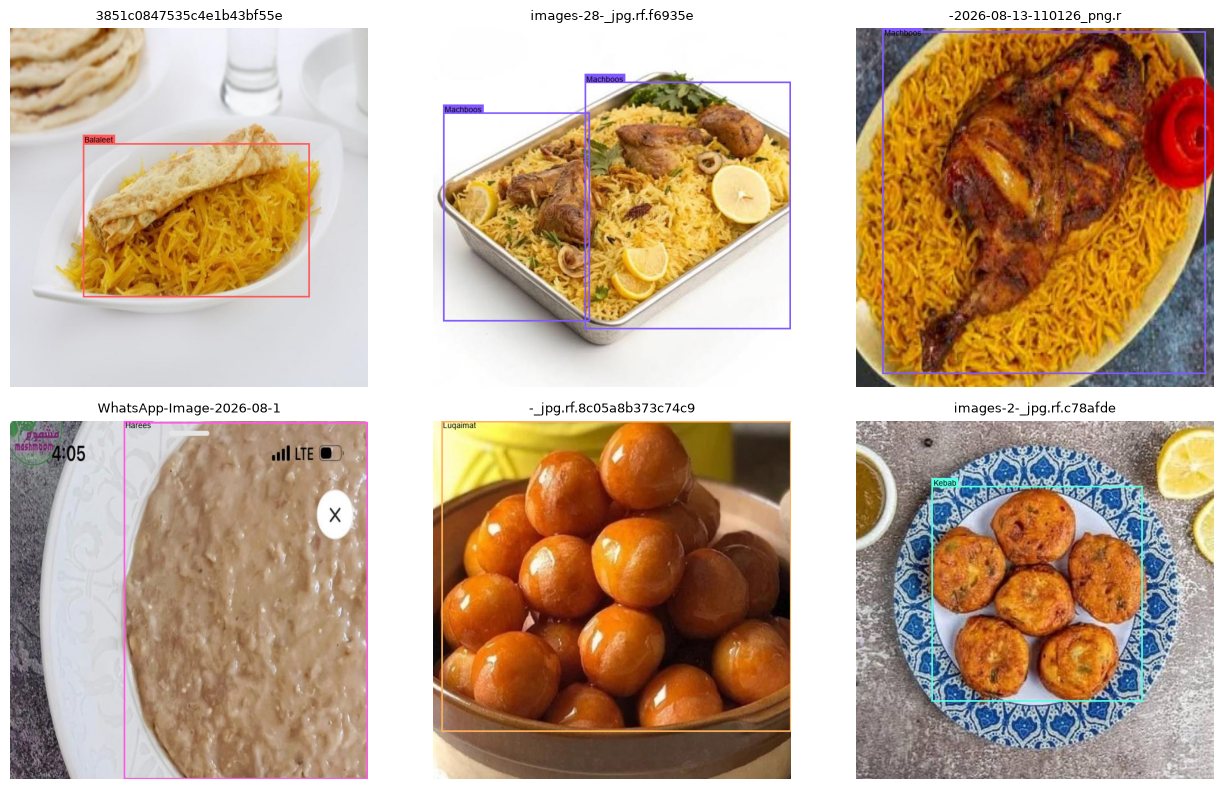

In [13]:
train_imgs = U.list_images(data["splits"]["train"]); random.seed(1)
sample = random.sample(train_imgs, min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(13, 8)); axes = axes.ravel()
for ax, img_path in zip(axes, sample):
    W, H = Image.open(img_path).size
    lab = U.read_yolo_label(U.label_path_for_image(img_path))
    boxes = [U.xywhn_to_xyxy(r[1:5], W, H) for r in lab]
    cls = lab[:, 0].astype(int).tolist()
    ann = U.draw_boxes(img_path, boxes, [data["names"][c] for c in cls], class_ids=cls)
    ax.imshow(ann); ax.set_title(os.path.basename(img_path)[:24], fontsize=9); ax.axis("off")
for ax in axes[len(sample):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7 · Possibly-questionable annotations
Auto-flag **very small** boxes (< 1.5% of image area) and boxes **touching the image edge**.
These are the ones most worth reviewing by hand.

In [14]:
flagged = []
for s, d in data["splits"].items():
    for img in U.list_images(d):
        lab = U.read_yolo_label(U.label_path_for_image(img))
        for r in lab:
            _, xc, yc, w, h = r
            area = w * h
            edge = (xc - w/2 <= 0.005) or (yc - h/2 <= 0.005) or (xc + w/2 >= 0.995) or (yc + h/2 >= 0.995)
            if area < 0.015 or edge:
                flagged.append({"image": os.path.basename(img),
                                "class": data["names"][int(r[0])],
                                "area_%": round(area * 100, 2),
                                "touches_edge": bool(edge)})
qdf = pd.DataFrame(flagged)
print(len(qdf), "boxes flagged for review (tiny or edge-touching)")
display(qdf.head(20))

299 boxes flagged for review (tiny or edge-touching)


,image,class,area_%,touches_edge
0,-2026-08-13-101712_png.rf.6cccdbf8e9d47aa93a28...,Samboosa,81.08,True
1,-2026-08-13-101914_png.rf.11095b18886e3b1ceb8d...,Samboosa,50.25,True
2,-2026-08-13-102238_png.rf.4c393bb6b1e01343fab6...,Samboosa,94.59,True
3,-2026-08-13-102307_png.rf.e0ecd0675d21e65501c5...,Samboosa,32.86,True
4,-2026-08-13-102342_png.rf.8574ce8ae1ee8fbf0239...,Samboosa,83.05,True
5,-2026-08-13-103747_png.rf.b194ed59df772fe0a373...,Balaleet,41.83,True
6,-2026-08-13-103849_png.rf.5f8e08069102e2bbc602...,Balaleet,88.66,True
7,-2026-08-13-104054_png.rf.51bbc9a413727dcab629...,Balaleet,94.28,True
8,-2026-08-13-104123_png.rf.77fdee9225236814700e...,Balaleet,99.38,True
9,-2026-08-13-104145_png.rf.8a00f5c78e864e348b95...,Balaleet,90.10,True


## 8 · What to report (checklist)
- [x] number of images in train / validation / test  → *table in §1*
- [x] number of objects per class  → *table in §2*
- [x] number of images containing each class  → *table in §2*
- [x] average objects per image  → *§1*
- [x] chart of annotated objects per class  → *`results/objects_per_class.png`*
- [x] examples of good & questionable annotations  → *§6, §7*
- [x] any obvious class imbalance  → *§5*

**Next:** train the detector in `02_training.ipynb`.